In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
# ===== Step 1: Load and preprocess data =====
df = pd.read_csv("Preprocessed_Dataset_For_Prediction.csv")
df = pd.get_dummies(df, drop_first=True)

X = df.drop('churn_flag', axis=1)
y = df['churn_flag']

In [3]:
# ===== Step 2: Remove low variance features =====
vt = VarianceThreshold(threshold=0.01)
X_reduced = vt.fit_transform(X)
X_columns_reduced = X.columns[vt.get_support()]
X = pd.DataFrame(X_reduced, columns=X_columns_reduced)
print(f"[INFO] Features after low variance removal: {X.shape[1]}")

[INFO] Features after low variance removal: 12


In [4]:
# ===== Step 3: RFE function =====
def run_rfe_models(X, y, n_features):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        #"SVM (Linear)": SVC(kernel='linear'),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42)
    }

    rfe_results = {}

    for name, model in models.items():
        print(f"\n[INFO] Running RFE with: {name}")
        rfe = RFE(estimator=model, n_features_to_select=n_features, step=0.2)
        rfe.fit(X, y)
        selected_features = X.columns[rfe.support_].tolist()
        X_selected = X[selected_features]

        print(f"Selected Features ({name}): {selected_features}")
        rfe_results[name] = {
            "features": selected_features,
            "X_selected": X_selected
        }

    return rfe_results

In [5]:
# ===== Step 4: Classification function =====
def evaluate_classifiers(X, y, model_name, selected_features):
    results = []

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    # Feature Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    classifiers = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM (Linear)": SVC(kernel='linear'),
        "SVM (RBF)": SVC(kernel='rbf'),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier()
    }

    for clf_name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        # Store results
        results.append({
            "RFE Model": model_name,
            "Classifier": clf_name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1 Score": round(f1, 4),
            "Confusion Matrix": cm,
            "Features Used": selected_features
        })

    return results

In [6]:
# ===== Step 5: Run RFE and Evaluate =====
n_features = 3
rfe_outputs = run_rfe_models(X, y, n_features=n_features)

all_results = []

for rfe_model, rfe_data in rfe_outputs.items():
    selected_X = rfe_data["X_selected"]
    selected_features = rfe_data["features"]
    model_results = evaluate_classifiers(selected_X, y, rfe_model, selected_features)
    all_results.extend(model_results)


[INFO] Running RFE with: Logistic Regression


C:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Selected Features (Logistic Regression): ['auto_renew_flag', 'satisfaction_score', 'no_feedback']

[INFO] Running RFE with: Random Forest
Selected Features (Random Forest): ['mrr_amount', 'seats', 'usage_count']

[INFO] Running RFE with: Decision Tree
Selected Features (Decision Tree): ['Unnamed: 0', 'usage_count', 'resolution_time_hours']


In [7]:
# ===== Step 6: Convert to DataFrame and Display =====
results_df = pd.DataFrame(all_results)
print("\n✅ Classification Results Summary:\n")
results_df[["RFE Model", "Classifier", "Accuracy", "Precision", "Recall", "F1 Score"]]


✅ Classification Results Summary:



,RFE Model,Classifier,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Logistic Regression,0.592,0.6228,0.8987,0.7358
1,Logistic Regression,SVM (Linear),0.592,0.6228,0.8987,0.7358
2,Logistic Regression,SVM (RBF),0.592,0.6250,0.8861,0.7330
3,Logistic Regression,KNN,0.624,0.6633,0.8228,0.7345
4,Logistic Regression,Naive Bayes,0.592,0.6250,0.8861,0.7330
5,Logistic Regression,Decision Tree,0.592,0.6795,0.6709,0.6752
6,Logistic Regression,Random Forest,0.616,0.6667,0.7848,0.7209
7,Random Forest,Logistic Regression,0.600,0.6408,0.8354,0.7253
8,Random Forest,SVM (Linear),0.632,0.6320,1.0000,0.7745
9,Random Forest,SVM (RBF),0.600,0.6306,0.8861,0.7368


In [8]:
# ===== Step 7: Optional - Confusion Matrix Plot =====
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


📊 Example Confusion Matrix:


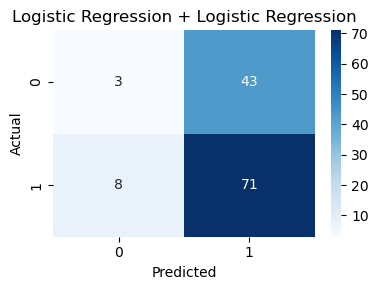

In [9]:
# Example: Plot for one result
print("\n📊 Example Confusion Matrix:")
plot_confusion_matrix(results_df.iloc[0]["Confusion Matrix"], 
                      f'{results_df.iloc[0]["RFE Model"]} + {results_df.iloc[0]["Classifier"]}')